# Supervised Machine Learning – Online Shopping Prediction

## 1. Syfte och frågeställning
## 2. Importera bibliotek och data
## 3. Förstå datasetet
## 4. EDA – undersöka variabler och relationer
## 5. Förbereda data för modellering
## 6. Modell 1: Logistic Regression
## 7. Modell 2: KNN
## 8. Modell 3: PCA + KNN eller PCA + Logistic Regression
## 9. Jämförelse av modeller
## 10. Slutsats och databerättelse

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

In [3]:
train_df = pd.read_csv("../../data/training_sample_svenska.csv")
test_df = pd.read_csv("../../data/testing_sample_svenska.csv")

train_df.head()

,anvandar_id,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


In [4]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.info()

Training shape: (455401, 25)
Testing shape: (151655, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455401 entries, 0 to 455400
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   anvandar_id                     455401 non-null  object
 1   klickat_varukorgsikon           455401 non-null  int64 
 2   lagt_till_fran_kategorisida     455401 non-null  int64 
 3   lagt_till_fran_produktsida      455401 non-null  int64 
 4   anvant_sorteringsfunktion       455401 non-null  int64 
 5   klickat_pa_produktbild          455401 non-null  int64 
 6   gatt_in_pa_kontosida            455401 non-null  int64 
 7   klickat_pa_kampanjbanner        455401 non-null  int64 
 8   sparat_i_onskelista             455401 non-null  int64 
 9   anvant_prissortering            455401 non-null  int64 
 10  stangt_liten_varukorg_popup     455401 non-null  int64 
 11  kollat_fraktkostnad             45

In [5]:
train_df.describe()

,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,stangt_liten_varukorg_popup,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
count,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,...,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000
mean,0.099150,0.074521,0.112916,0.036849,0.026735,0.003570,0.016208,0.003511,0.230362,0.017277,...,0.000389,0.005542,0.001096,0.290024,0.680706,0.194220,0.128364,0.534915,0.933224,0.041926
std,0.298864,0.262617,0.316490,0.188391,0.161307,0.059647,0.126274,0.059151,0.421065,0.130302,...,0.019711,0.074241,0.033084,0.453773,0.466204,0.395599,0.334495,0.498780,0.249634,0.200420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
train_df.isnull().sum()

anvandar_id                       0
klickat_varukorgsikon             0
lagt_till_fran_kategorisida       0
lagt_till_fran_produktsida        0
anvant_sorteringsfunktion         0
klickat_pa_produktbild            0
gatt_in_pa_kontosida              0
klickat_pa_kampanjbanner          0
sparat_i_onskelista               0
anvant_prissortering              0
stangt_liten_varukorg_popup       0
kollat_fraktkostnad               0
kollat_angerratt                  0
loggat_in                         0
gatt_till_kassan                  0
gatt_till_produktspecifikation    0
gatt_till_leveransvillkor         0
tomt_varukorg                     0
gatt_till_startsidan              0
anvant_mobil                      0
anvant_dator                      0
anvant_surfplatta                 0
aterkommande_besokare             0
besokt_fran_svensk_plats          0
genomfort_bestallning             0
dtype: int64

Datasetet innehåller information om användarbeteenden på en webbshop. Varje rad representerar en besökare/session och variablerna visar olika klick eller handlingar, till exempel om personen klickade på varukorgen, loggade in, gick till kassan eller använde mobil/dator. Målvariabeln är `genomfort_bestallning`, som visar om besökaren faktiskt genomförde en beställning eller inte.

In [7]:
train_df["genomfort_bestallning"].value_counts()

genomfort_bestallning
0    436308
1     19093
Name: count, dtype: int64

In [8]:
train_df["genomfort_bestallning"].value_counts(normalize=True) * 100

genomfort_bestallning
0    95.807431
1     4.192569
Name: proportion, dtype: float64

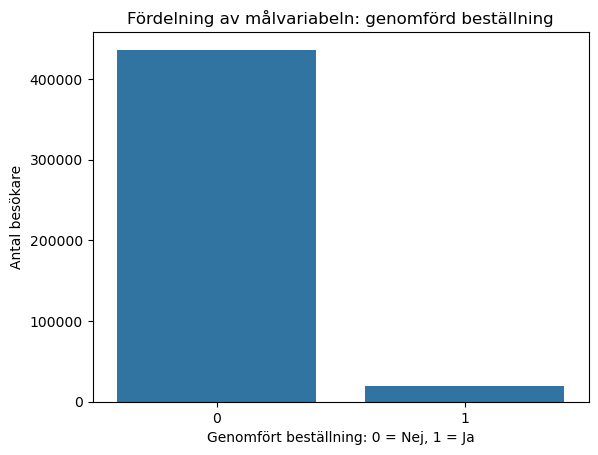

In [9]:
sns.countplot(data=train_df, x="genomfort_bestallning")
plt.title("Fördelning av målvariabeln: genomförd beställning")
plt.xlabel("Genomfört beställning: 0 = Nej, 1 = Ja")
plt.ylabel("Antal besökare")
plt.show()

Här ser vi att datasetet är obalanserat. De flesta besökare genomför inte en beställning, medan en mindre andel faktiskt beställer. Därför räcker det inte att bara titta på accuracy. Vi behöver också titta på precision, recall, F1-score och gärna Precision-Recall-kurva.

Kan vi förstå vilka klickbeteenden som visar att en kund är nära att köpa?

Vi analyserar besökarnas beteende på en webbshop. Vissa handlingar, som att gå till kassan, logga in eller lägga till varor, kan vara starka signaler på köpintention. Med supervised machine learning testar vi om modellen kan lära sig dessa mönster och förutsäga om en besökare kommer att genomföra en beställning.

In [10]:
X = train_df.drop(columns=["anvandar_id", "genomfort_bestallning"])
y = train_df["genomfort_bestallning"]

X.head()

,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,stangt_liten_varukorg_popup,...,gatt_till_kassan,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,0,1,0,1,0,0,0,0,1,0,...,1,0,0,0,1,0,0,1,0,1


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_val distribution:")
print(y_val.value_counts(normalize=True))

X_train: (364320, 23)
X_val: (91081, 23)
y_train distribution:
genomfort_bestallning
0    0.958075
1    0.041925
Name: proportion, dtype: float64
y_val distribution:
genomfort_bestallning
0    0.95807
1    0.04193
Name: proportion, dtype: float64


In [12]:
features = X.columns

conversion_rates = []

for col in features:
    rate_when_0 = train_df[train_df[col] == 0]["genomfort_bestallning"].mean()
    rate_when_1 = train_df[train_df[col] == 1]["genomfort_bestallning"].mean()
    diff = rate_when_1 - rate_when_0
    
    conversion_rates.append({
        "variabel": col,
        "köpandel_när_0": rate_when_0,
        "köpandel_när_1": rate_when_1,
        "skillnad": diff
    })

conversion_df = pd.DataFrame(conversion_rates)
conversion_df = conversion_df.sort_values("skillnad", ascending=False)

conversion_df.head(10)

,variabel,köpandel_när_0,köpandel_när_1,skillnad
10,kollat_fraktkostnad,0.000462,0.659938,0.659476
13,gatt_till_kassan,0.000000,0.523512,0.523512
12,loggat_in,0.000282,0.469192,0.468910
0,klickat_varukorgsikon,0.013446,0.300689,0.287243
2,lagt_till_fran_produktsida,0.012293,0.274727,0.262434
1,lagt_till_fran_kategorisida,0.025566,0.245101,0.219536
9,stangt_liten_varukorg_popup,0.038205,0.253559,0.215354
5,gatt_in_pa_kontosida,0.041238,0.233702,0.192464
16,tomt_varukorg,0.041754,0.198397,0.156643
11,kollat_angerratt,0.040778,0.165789,0.125011


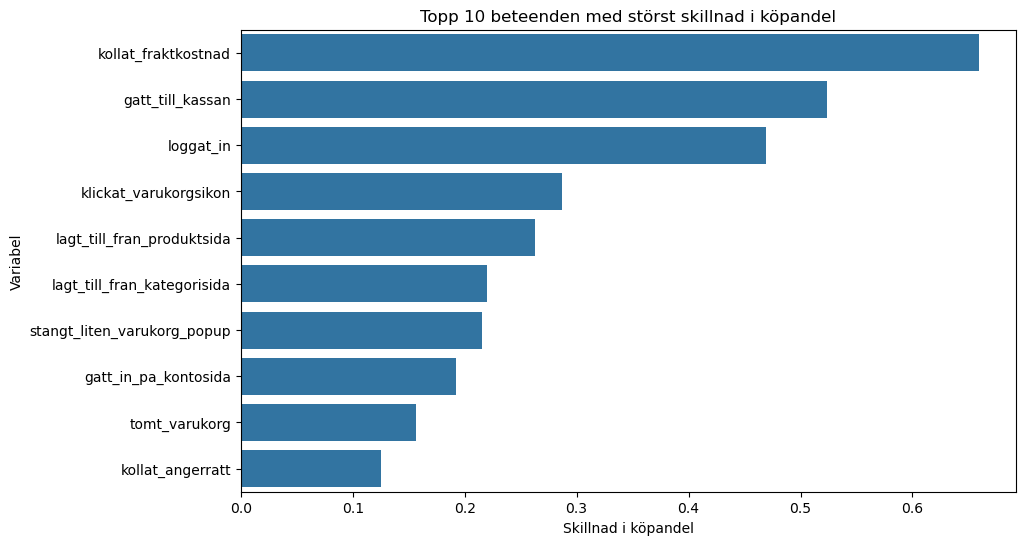

In [13]:
top_10 = conversion_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x="skillnad", y="variabel")
plt.title("Topp 10 beteenden med störst skillnad i köpandel")
plt.xlabel("Skillnad i köpandel")
plt.ylabel("Variabel")
plt.show()

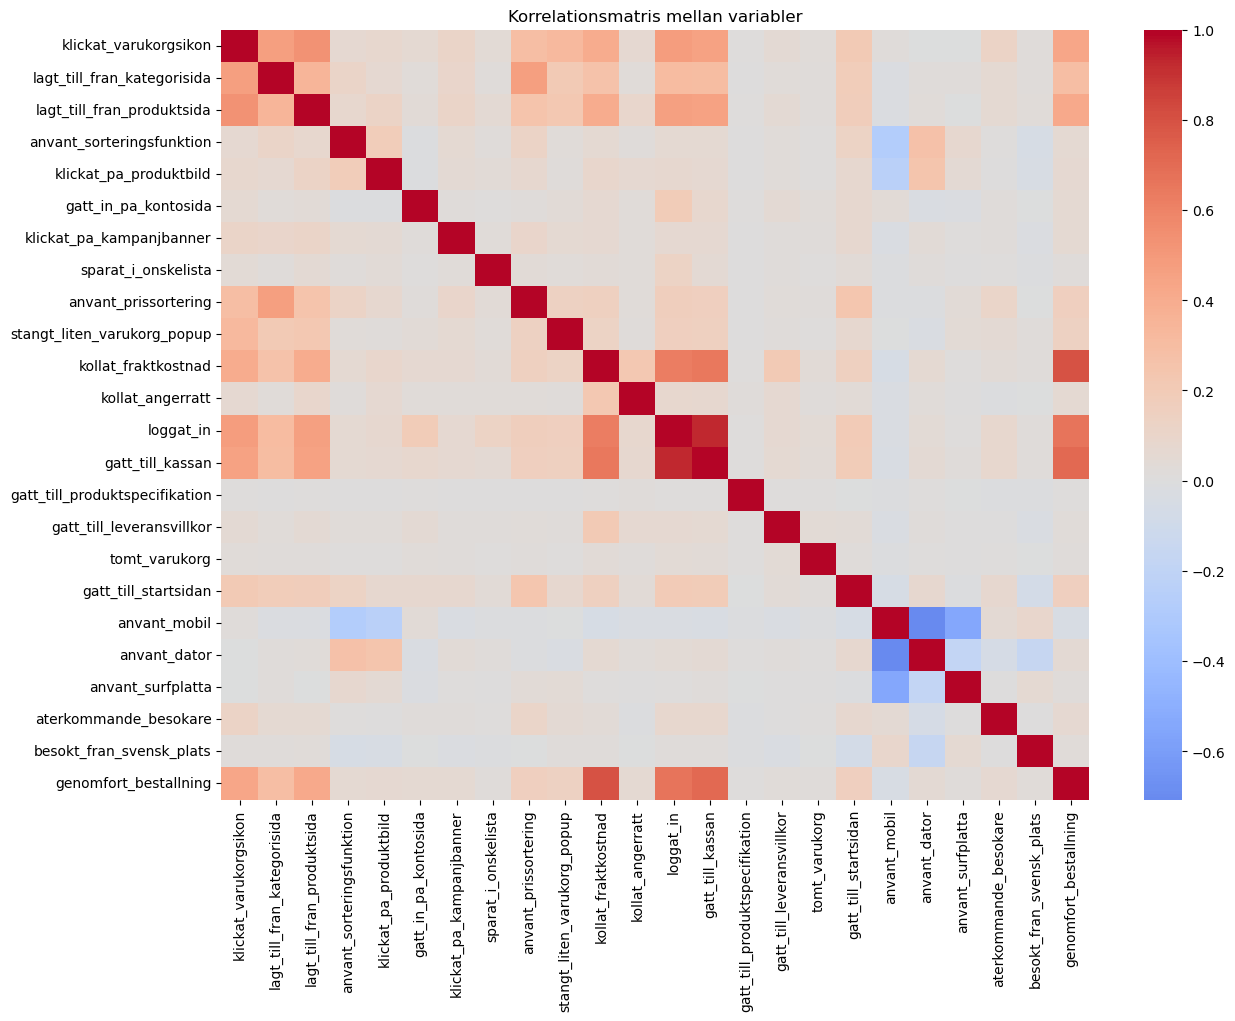

In [14]:
corr = train_df.drop(columns=["anvandar_id"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Korrelationsmatris mellan variabler")
plt.show()

In [15]:
target_corr = corr["genomfort_bestallning"].sort_values(ascending=False)

target_corr

genomfort_bestallning             1.000000
kollat_fraktkostnad               0.798720
gatt_till_kassan                  0.708986
loggat_in                         0.665556
klickat_varukorgsikon             0.428334
lagt_till_fran_produktsida        0.414420
lagt_till_fran_kategorisida       0.287666
gatt_till_startsidan              0.157778
anvant_prissortering              0.154867
stangt_liten_varukorg_popup       0.140011
klickat_pa_produktbild            0.071492
aterkommande_besokare             0.060295
kollat_angerratt                  0.059484
gatt_in_pa_kontosida              0.057279
klickat_pa_kampanjbanner          0.056533
anvant_sorteringsfunktion         0.054636
anvant_dator                      0.049208
besokt_fran_svensk_plats          0.031643
gatt_till_leveransvillkor         0.031461
tomt_varukorg                     0.025857
sparat_i_onskelista               0.023516
anvant_surfplatta                 0.016939
gatt_till_produktspecifikation    0.007548
anvant_mobi

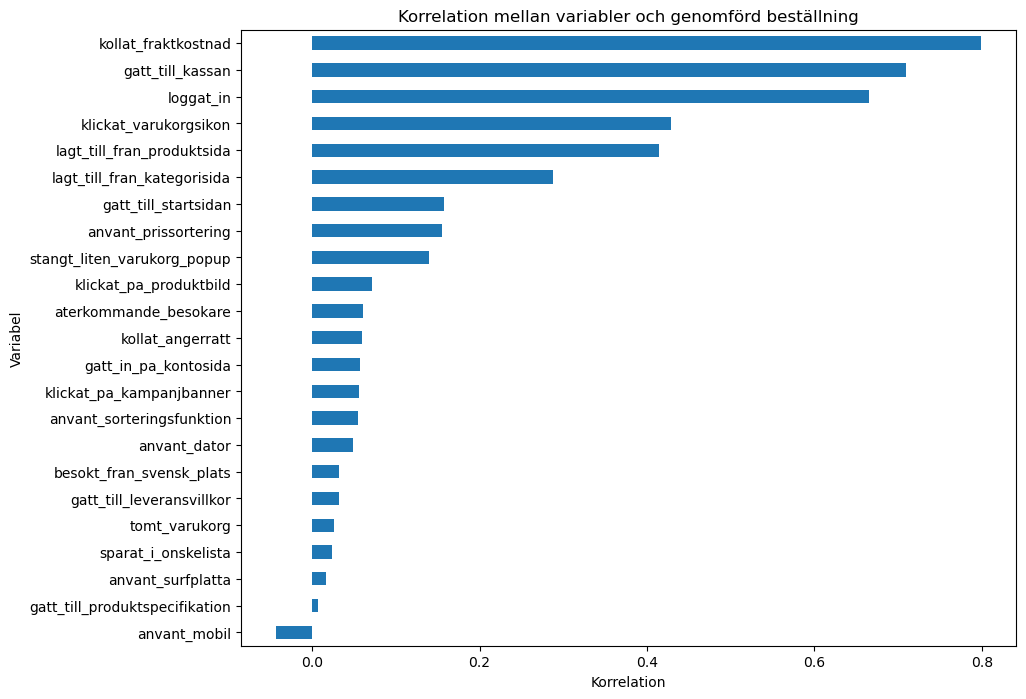

In [16]:
target_corr.drop("genomfort_bestallning").sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Korrelation mellan variabler och genomförd beställning")
plt.xlabel("Korrelation")
plt.ylabel("Variabel")
plt.show()

Målvariabeln `genomfort_bestallning` är tydligt obalanserad. Cirka 95.8 % av besökarna genomförde inte en beställning, medan endast cirka 4.2 % gjorde det. Det betyder att modellen kan få hög accuracy genom att nästan alltid förutsäga klass 0. Därför behöver vi använda flera utvärderingsmått, särskilt precision, recall och F1-score för klass 1.

Korrelationsanalysen visar samma mönster som köpandelsanalysen. Variabler som `kollat_fraktkostnad`, `gatt_till_kassan` och `loggat_in` har starkast positiv korrelation med målvariabeln `genomfort_bestallning`. Det betyder att dessa beteenden är viktiga indikatorer för om en besökare kommer att genomföra en beställning.

EDA:n visar att vissa beteenden har en mycket stark relation till genomförd beställning. Den tydligaste variabeln är `kollat_fraktkostnad`, där köpandelen är mycket högre bland besökare som har kontrollerat fraktkostnad. Även `gatt_till_kassan`, `loggat_in`, `klickat_varukorgsikon` och `lagt_till_fran_produktsida` verkar vara starka signaler på köpintention.

Detta är logiskt ur ett webbshop-perspektiv. En besökare som kontrollerar fraktkostnad, går till kassan eller loggar in har troligen kommit längre i köpresan än en besökare som bara tittar runt på sidan.

Här ser vi att alla klick inte betyder samma sak. Att bara besöka sidan är svagare signal, men att gå till kassan, logga in eller kolla fraktkostnad visar att kunden är mycket närmare ett köp.

In [17]:
# Skala data för Logistic Regression och KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [18]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_val_scaled)
y_proba_log = log_model.predict_proba(X_val_scaled)[:, 1]

In [19]:
print("Accuracy:", accuracy_score(y_val, y_pred_log))
print("Precision:", precision_score(y_val, y_pred_log))
print("Recall:", recall_score(y_val, y_pred_log))
print("F1-score:", f1_score(y_val, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_log))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))

Accuracy: 0.9920400522611741
Precision: 0.8450044603033007
Recall: 0.9921445404556166
F1-score: 0.9126821630735878
ROC-AUC: 0.9973997353450771

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.85      0.99      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.92      0.99      0.95     91081
weighted avg       0.99      0.99      0.99     91081



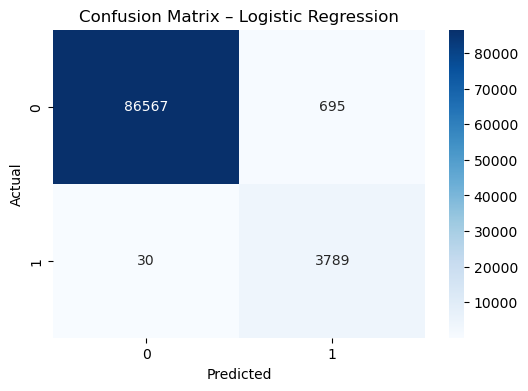

In [20]:
cm = confusion_matrix(y_val, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

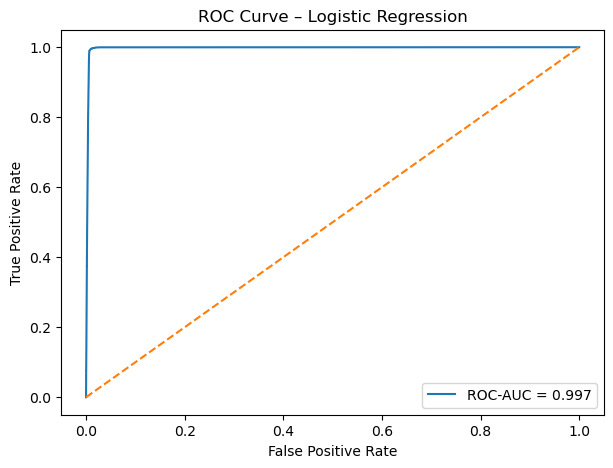

In [21]:
fpr, tpr, thresholds = roc_curve(y_val, y_proba_log)
auc_score = roc_auc_score(y_val, y_proba_log)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve – Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Modellen presterar väldigt bra, men vi behöver komma ihåg att vissa variabler är mycket nära själva köptillfället, till exempel att gå till kassan eller kontrollera fraktkostnad. Därför är modellen stark, men resultatet ska tolkas i relation till kundresan.

##  Modell 2: KNN

I den här delen testar jag K-Nearest Neighbors (KNN) som en andra supervised learning-modell.  
KNN jämför nya datapunkter med de närmaste datapunkterna i träningsdatan. Eftersom KNN är avståndsbaserad behöver datan skalas innan modellen tränas.

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_val_scaled)
y_proba_knn = knn_model.predict_proba(X_val_scaled)[:, 1]

In [23]:
print("KNN Results")
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("Precision:", precision_score(y_val, y_pred_knn))
print("Recall:", recall_score(y_val, y_pred_knn))
print("F1-score:", f1_score(y_val, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_knn))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn))

KNN Results
Accuracy: 0.9919302598785696
Precision: 0.8692528735632183
Recall: 0.950510604870385
F1-score: 0.9080675422138836
ROC-AUC: 0.9921975436374759

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.95      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.97      0.95     91081
weighted avg       0.99      0.99      0.99     91081



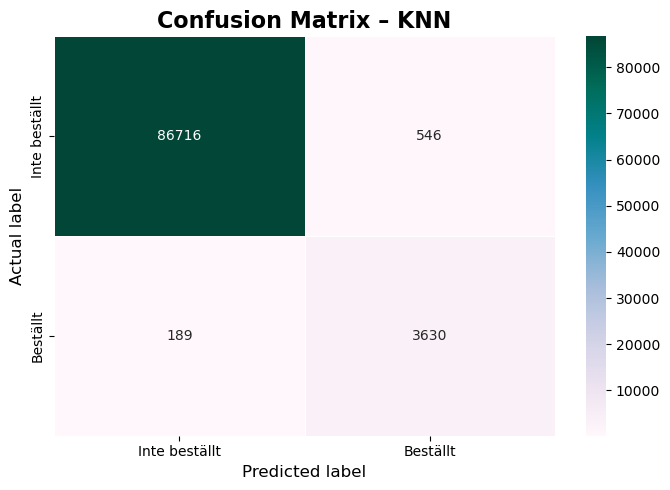

In [24]:
cm_knn = confusion_matrix(y_val, y_pred_knn)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Inte beställt", "Beställt"],
    yticklabels=["Inte beställt", "Beställt"]
)

plt.title("Confusion Matrix – KNN", fontsize=16, fontweight="bold")
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("Actual label", fontsize=12)
plt.tight_layout()
plt.show()

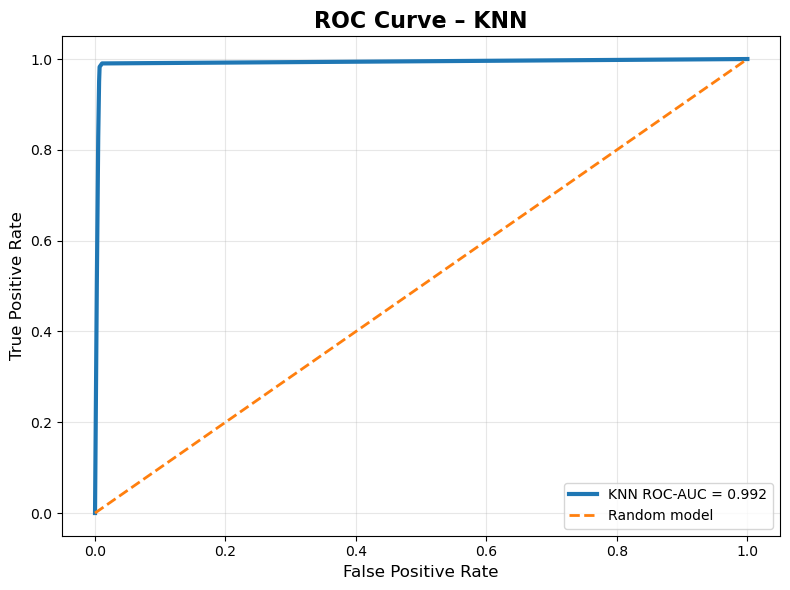

In [25]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_val, y_proba_knn)
auc_knn = roc_auc_score(y_val, y_proba_knn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=3,
    label=f"KNN ROC-AUC = {auc_knn:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random model"
)

plt.title("ROC Curve – KNN", fontsize=16, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Logistic Regression:
Accuracy: 0.9920
Precision: 0.8450
Recall: 0.9921
F1-score: 0.9127
ROC-AUC: 0.9974

KNN:
Accuracy: 0.9919
Precision: 0.8693
Recall: 0.9505
F1-score: 0.9081
ROC-AUC: 0.9922

### Tolkning av KNN-resultatet

KNN-modellen presterar mycket bra på validation-datan. Modellen får hög accuracy, hög precision och hög recall för klass 1, vilket betyder att den kan identifiera många av de besökare som faktiskt genomför en beställning.

Jämfört med Logistic Regression har KNN något högre precision men lägre recall. Det betyder att KNN är något mer försiktig när den förutsäger beställning, medan Logistic Regression hittar fler av de faktiska beställningarna.

Eftersom datasetet är obalanserat är recall och F1-score för klass 1 extra viktiga. Både Logistic Regression och KNN fungerar bra, men Logistic Regression verkar vara något starkare totalt eftersom den har högre recall och ROC-AUC.

In [26]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_knn)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_knn)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.99204,0.845004,0.992145,0.912682,0.997400
1,KNN,0.99193,0.869253,0.950511,0.908068,0.992198


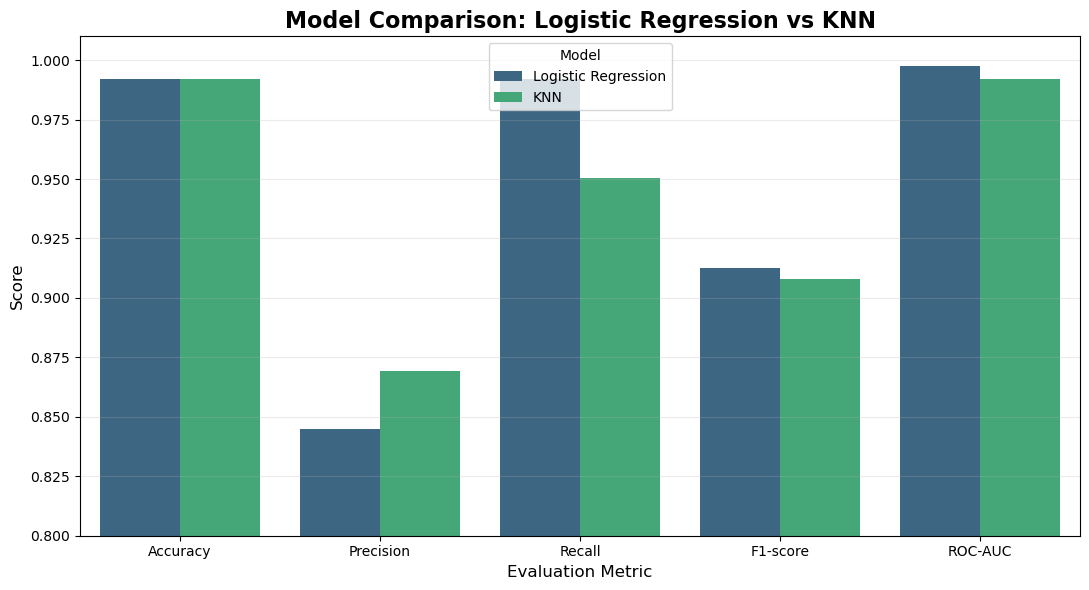

In [27]:
comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="viridis"
)

plt.title("Model Comparison: Logistic Regression vs KNN", fontsize=16, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Jämförelse mellan Logistic Regression och KNN

Båda modellerna presterar mycket bra på validation-datan. KNN har något högre precision, vilket betyder att modellen är lite mer säker när den förutsäger att en besökare kommer att genomföra en beställning.

Logistic Regression har däremot högre recall och ROC-AUC. Det betyder att Logistic Regression hittar fler av de faktiska beställningarna och är bättre på att skilja mellan klass 0 och klass 1.

Eftersom datasetet är obalanserat och klass 1 är den viktigaste klassen i detta case, är recall och F1-score extra viktiga. Därför bedömer jag att Logistic Regression är den starkaste modellen hittills.

##  PCA + KNN

I den här delen kombinerar jag PCA med KNN. PCA används för att minska antalet dimensioner i datan och behålla så mycket information som möjligt. Eftersom KNN är avståndsbaserad kan PCA ibland hjälpa modellen genom att minska brus och göra avståndsberäkningen mer stabil.

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

Original number of features: 23
Number of PCA components: 19
Explained variance ratio: 0.9623908603122668


In [29]:
knn_pca_model = KNeighborsClassifier(n_neighbors=5)

knn_pca_model.fit(X_train_pca, y_train)

y_pred_knn_pca = knn_pca_model.predict(X_val_pca)
y_proba_knn_pca = knn_pca_model.predict_proba(X_val_pca)[:, 1]

In [30]:
print("KNN + PCA Results")
print("Accuracy:", accuracy_score(y_val, y_pred_knn_pca))
print("Precision:", precision_score(y_val, y_pred_knn_pca))
print("Recall:", recall_score(y_val, y_pred_knn_pca))
print("F1-score:", f1_score(y_val, y_pred_knn_pca))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_knn_pca))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn_pca))

KNN + PCA Results
Accuracy: 0.9916777373985793
Precision: 0.8695967157691379
Recall: 0.942916993977481
F1-score: 0.9047738693467337
ROC-AUC: 0.9911273645800135

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.94      0.90      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.97      0.95     91081
weighted avg       0.99      0.99      0.99     91081



### Tolkning av KNN + PCA

KNN + PCA presterar fortfarande mycket bra, men resultatet är något lägre än både Logistic Regression och vanlig KNN. Precisionen är ungefär på samma nivå som KNN, men recall och F1-score minskar något.

Det betyder att PCA inte förbättrade modellen i detta case. En möjlig förklaring är att datasetet redan har relativt få feature-variabler och att variablerna redan är binära och tydliga. När PCA komprimerar informationen kan vissa små men viktiga signaler för klass 1 försvagas.

Därför verkar PCA inte vara nödvändigt för detta dataset, även om det var värdefullt att testa metoden.

In [31]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "KNN + PCA"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_knn),
        accuracy_score(y_val, y_pred_knn_pca)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_knn),
        precision_score(y_val, y_pred_knn_pca)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_knn),
        recall_score(y_val, y_pred_knn_pca)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_knn),
        f1_score(y_val, y_pred_knn_pca)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_knn),
        roc_auc_score(y_val, y_proba_knn_pca)
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.992040,0.845004,0.992145,0.912682,0.997400
1,KNN,0.991930,0.869253,0.950511,0.908068,0.992198
2,KNN + PCA,0.991678,0.869597,0.942917,0.904774,0.991127


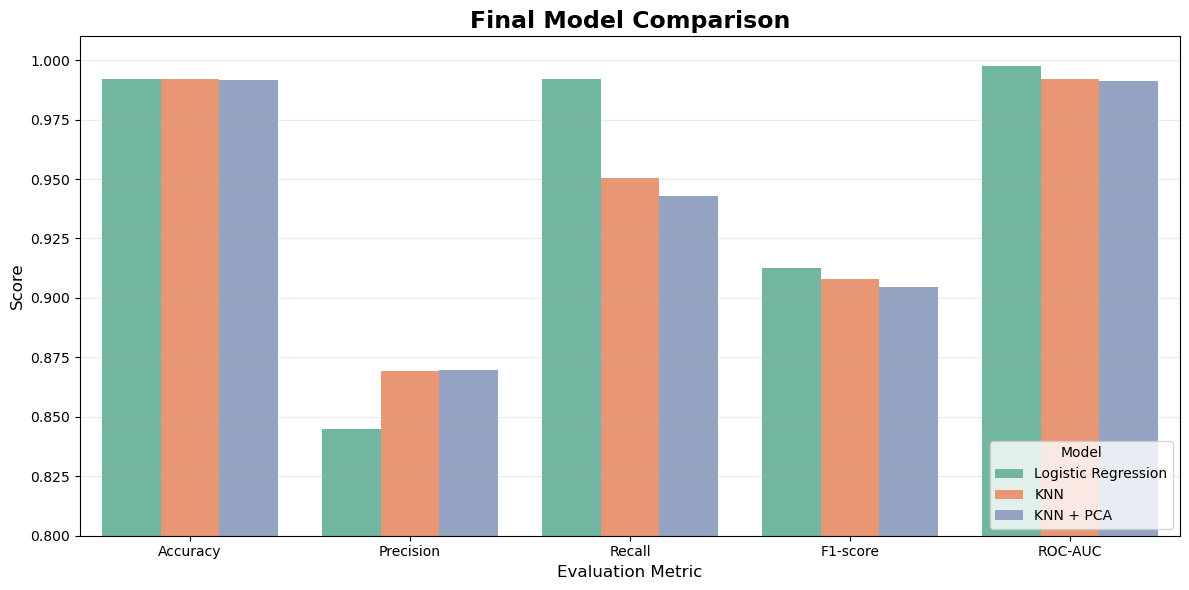

In [32]:
final_long = final_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.title("Final Model Comparison", fontsize=17, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.legend(title="Model", loc="lower right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

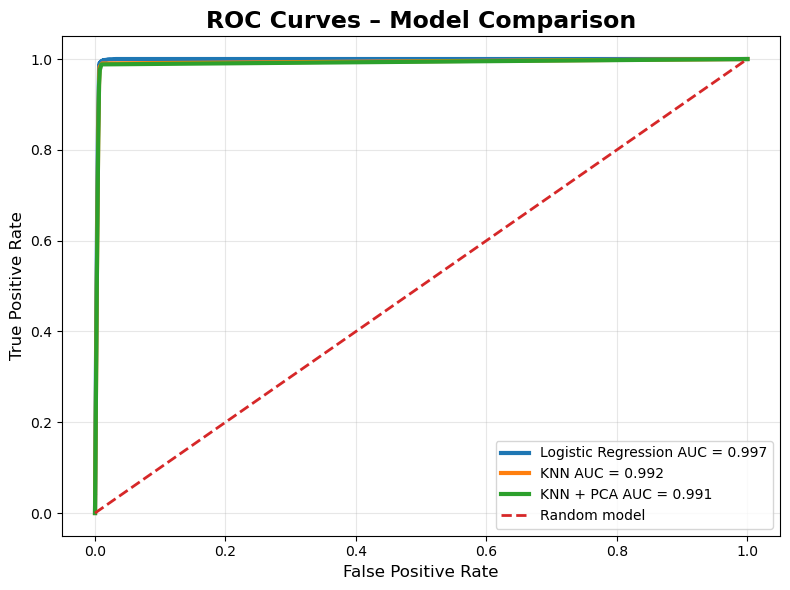

In [33]:
fpr_log, tpr_log, _ = roc_curve(y_val, y_proba_log)
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_proba_knn)
fpr_knn_pca, tpr_knn_pca, _ = roc_curve(y_val, y_proba_knn_pca)

auc_log = roc_auc_score(y_val, y_proba_log)
auc_knn = roc_auc_score(y_val, y_proba_knn)
auc_knn_pca = roc_auc_score(y_val, y_proba_knn_pca)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, linewidth=3, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot(fpr_knn, tpr_knn, linewidth=3, label=f"KNN AUC = {auc_knn:.3f}")
plt.plot(fpr_knn_pca, tpr_knn_pca, linewidth=3, label=f"KNN + PCA AUC = {auc_knn_pca:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random model")

plt.title("ROC Curves – Model Comparison", fontsize=17, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. KNN Optimization – Testa olika k-värden

I den här delen testar jag flera olika k-värden för KNN. Målet är att se om modellen blir bättre eller mer stabil när antalet grannar ändras. Eftersom KNN är avståndsbaserad använder jag den skalade datan.

In [34]:
k_values = [3, 5, 7, 9, 11, 15]

knn_results = []

for k in k_values:
    print(f"Training KNN with k={k}...")
    
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    knn_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba)
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

Training KNN with k=3...
Training KNN with k=5...
Training KNN with k=7...
Training KNN with k=9...
Training KNN with k=11...
Training KNN with k=15...


,k,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,3,0.990261,0.870202,0.902330,0.885975,0.990049
1,5,0.991930,0.869253,0.950511,0.908068,0.992198
2,7,0.992523,0.868310,0.968578,0.915707,0.993432
3,9,0.992567,0.867399,0.971197,0.916368,0.993673
4,11,0.992611,0.867352,0.972506,0.916924,0.994068
5,15,0.992798,0.868734,0.975648,0.919092,0.994837


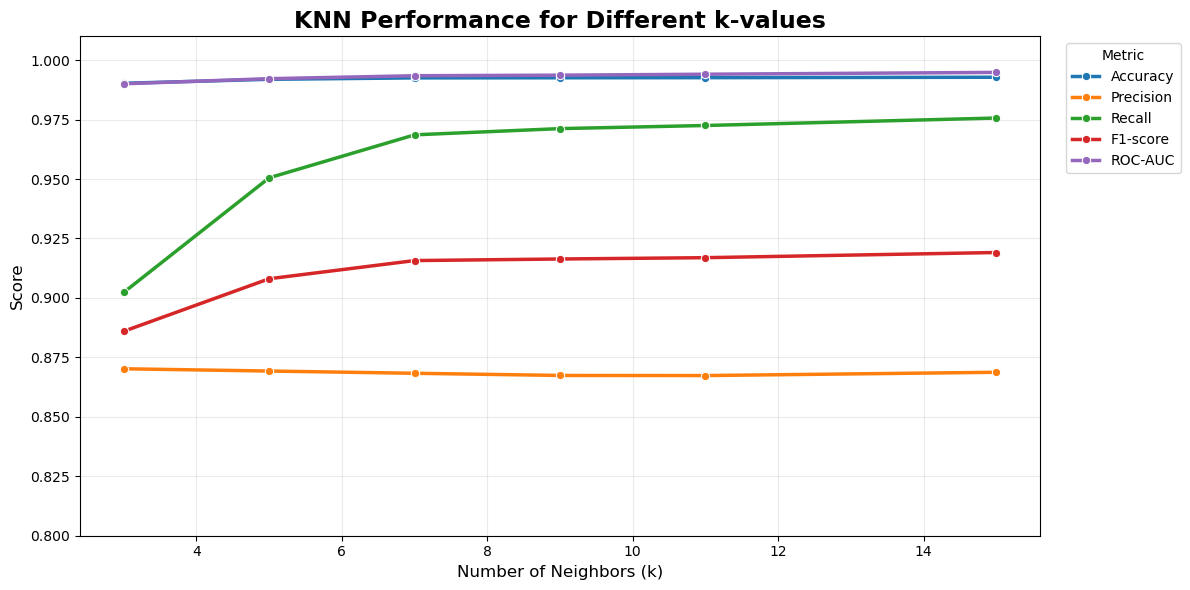

In [35]:
knn_results_long = knn_results_df.melt(
    id_vars="k",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=knn_results_long,
    x="k",
    y="Score",
    hue="Metric",
    marker="o",
    linewidth=2.5
)

plt.title("KNN Performance for Different k-values", fontsize=17, fontweight="bold")
plt.xlabel("Number of Neighbors (k)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.grid(alpha=0.25)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Tolkning av KNN-optimering

KNN tog relativt lång tid att köra eftersom datasetet är stort. Det är förväntat eftersom KNN är en avståndsbaserad och instansbaserad modell. Vid varje prediktion jämför modellen nya observationer med många observationer i träningsdatan.

Resultatet visar att högre k-värden gav bättre recall, F1-score och ROC-AUC. Det betyder att modellen blev bättre på att hitta faktiska beställningar när antalet grannar ökade. Precisionen låg relativt stabilt runt 0.87.

Av de testade värdena gav k=15 bäst helhetsresultat, med högst recall, F1-score och ROC-AUC. Därför är k=15 det bästa KNN-valet i denna jämförelse.

##  Optimized KNN – bästa k-värdet

Efter att ha testat flera olika k-värden visade resultatet att k=15 gav bäst helhetsresultat. Därför tränar jag en optimerad KNN-modell med 15 grannar och jämför den med de tidigare modellerna.

In [36]:
optimized_knn = KNeighborsClassifier(n_neighbors=15)

optimized_knn.fit(X_train_scaled, y_train)

y_pred_knn_opt = optimized_knn.predict(X_val_scaled)
y_proba_knn_opt = optimized_knn.predict_proba(X_val_scaled)[:, 1]

In [37]:
print("Optimized KNN Results (k=15)")
print("Accuracy:", accuracy_score(y_val, y_pred_knn_opt))
print("Precision:", precision_score(y_val, y_pred_knn_opt))
print("Recall:", recall_score(y_val, y_pred_knn_opt))
print("F1-score:", f1_score(y_val, y_pred_knn_opt))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_knn_opt))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn_opt))

Optimized KNN Results (k=15)
Accuracy: 0.9927976197011451
Precision: 0.8687339706225228
Recall: 0.9756480754124116
F1-score: 0.9190922545633942
ROC-AUC: 0.9948370261759047

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.98      0.92      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.98      0.96     91081
weighted avg       0.99      0.99      0.99     91081



In [38]:
optimized_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN k=5",
        "Optimized KNN k=15",
        "KNN + PCA"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_knn),
        accuracy_score(y_val, y_pred_knn_opt),
        accuracy_score(y_val, y_pred_knn_pca)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_knn),
        precision_score(y_val, y_pred_knn_opt),
        precision_score(y_val, y_pred_knn_pca)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_knn),
        recall_score(y_val, y_pred_knn_opt),
        recall_score(y_val, y_pred_knn_pca)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_knn),
        f1_score(y_val, y_pred_knn_opt),
        f1_score(y_val, y_pred_knn_pca)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_knn),
        roc_auc_score(y_val, y_proba_knn_opt),
        roc_auc_score(y_val, y_proba_knn_pca)
    ]
})

optimized_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.992040,0.845004,0.992145,0.912682,0.997400
1,KNN k=5,0.991930,0.869253,0.950511,0.908068,0.992198
2,Optimized KNN k=15,0.992798,0.868734,0.975648,0.919092,0.994837
3,KNN + PCA,0.991678,0.869597,0.942917,0.904774,0.991127


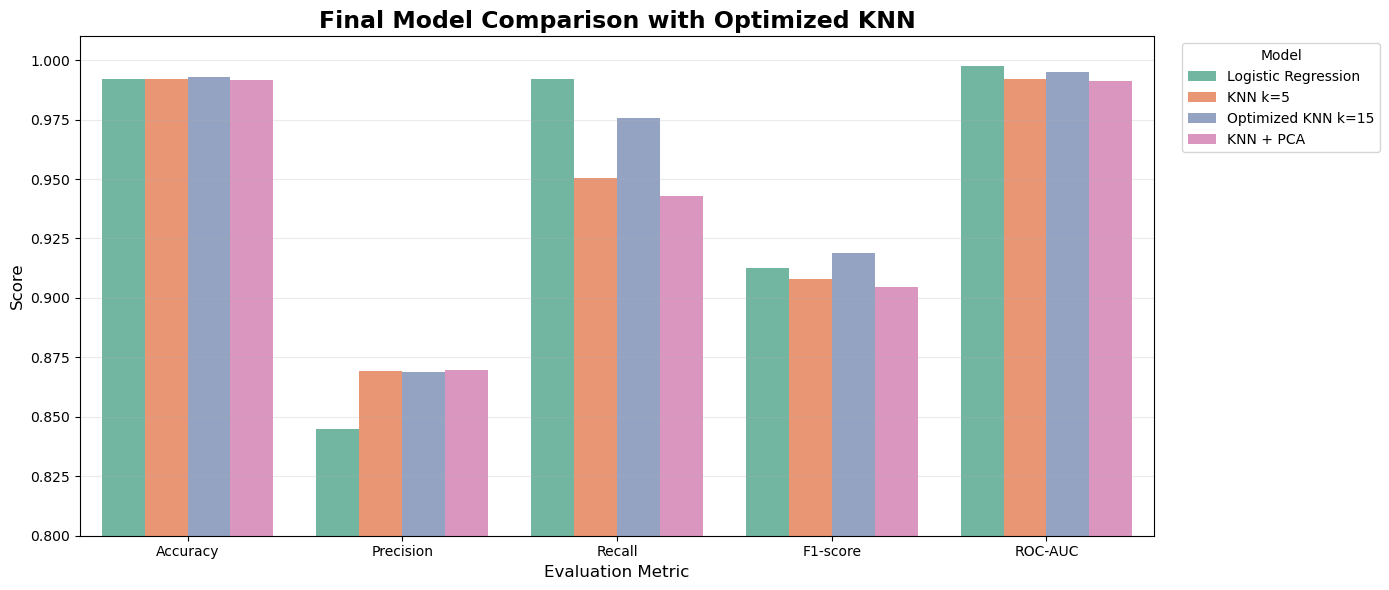

In [40]:
optimized_long = optimized_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=optimized_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.title("Final Model Comparison with Optimized KNN", fontsize=17, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Tolkning av Optimized KNN

Efter att ha testat flera olika k-värden förbättrades KNN-modellen. Det bästa testade värdet var k=15. Den optimerade KNN-modellen fick högre accuracy, recall, F1-score och ROC-AUC än standardmodellen med k=5.

Det betyder att hyperparameter tuning förbättrade modellens förmåga att identifiera besökare som faktiskt genomför en beställning.

Logistic Regression har fortfarande högst recall och ROC-AUC, men Optimized KNN har högst F1-score och något högre precision. Därför är båda modellerna starka, men de passar lite olika mål.

## 11. Precision-Recall Curve och AUPRC

Eftersom datasetet är obalanserat räcker det inte alltid att bara titta på accuracy och ROC-AUC.  
Därför analyserar jag också Precision-Recall Curve och AUPRC (Average Precision), som är särskilt användbara när den positiva klassen är ovanlig.

In [41]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Logistic Regression
precision_log, recall_log, _ = precision_recall_curve(y_val, y_proba_log)
ap_log = average_precision_score(y_val, y_proba_log)

# Optimized KNN
precision_knn_opt, recall_knn_opt, _ = precision_recall_curve(y_val, y_proba_knn_opt)
ap_knn_opt = average_precision_score(y_val, y_proba_knn_opt)

# KNN + PCA
precision_knn_pca, recall_knn_pca, _ = precision_recall_curve(y_val, y_proba_knn_pca)
ap_knn_pca = average_precision_score(y_val, y_proba_knn_pca)

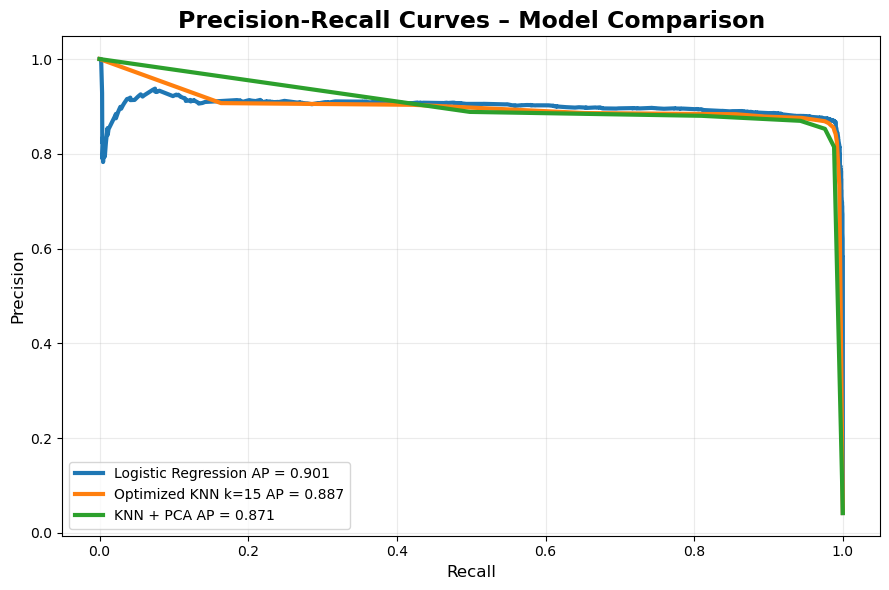

In [42]:
plt.figure(figsize=(9, 6))

plt.plot(
    recall_log,
    precision_log,
    linewidth=3,
    label=f"Logistic Regression AP = {ap_log:.3f}"
)

plt.plot(
    recall_knn_opt,
    precision_knn_opt,
    linewidth=3,
    label=f"Optimized KNN k=15 AP = {ap_knn_opt:.3f}"
)

plt.plot(
    recall_knn_pca,
    precision_knn_pca,
    linewidth=3,
    label=f"KNN + PCA AP = {ap_knn_pca:.3f}"
)

plt.title("Precision-Recall Curves – Model Comparison", fontsize=17, fontweight="bold")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Tolkning av Precision-Recall Curve

Precision-Recall Curve är särskilt viktig i detta projekt eftersom datasetet är obalanserat och den positiva klassen, alltså genomförd beställning, är relativt ovanlig.

En hög Average Precision (AUPRC) betyder att modellen lyckas hålla en bra balans mellan precision och recall över olika tröskelvärden.

Om en modell har högre AUPRC betyder det att den generellt är bättre på att identifiera faktiska beställningar utan att skapa för många falska positiva förutsägelser.

In [43]:
pr_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Optimized KNN k=15", "KNN + PCA"],
    "Average Precision (AUPRC)": [ap_log, ap_knn_opt, ap_knn_pca]
})

pr_comparison

,Model,Average Precision (AUPRC)
0,Logistic Regression,0.900522
1,Optimized KNN k=15,0.887113
2,KNN + PCA,0.871291


In [44]:
pr_comparison.sort_values("Average Precision (AUPRC)", ascending=False)

,Model,Average Precision (AUPRC)
0,Logistic Regression,0.900522
1,Optimized KNN k=15,0.887113
2,KNN + PCA,0.871291


### Tolkning av Precision-Recall Curve och AUPRC

Eftersom datasetet är obalanserat är Precision-Recall Curve extra viktig. Den fokuserar på den positiva klassen, alltså besökare som faktiskt genomför en beställning.

Resultatet visar att Logistic Regression har högst Average Precision (AUPRC), cirka 0.90. Det betyder att modellen har bäst balans mellan precision och recall över olika tröskelvärden.

Optimized KNN k=15 presterar också starkt, men når inte riktigt samma nivå som Logistic Regression. KNN + PCA har lägst AUPRC av de tre modellerna.

Detta stärker slutsatsen att Logistic Regression är den bästa modellen i detta case.

## 12. Threshold Optimization – Logistic Regression

Logistic Regression ger sannolikheter mellan 0 och 1. Som standard används tröskeln 0.5: om sannolikheten är minst 0.5 klassas besökaren som beställning.

Eftersom datasetet är obalanserat testar jag olika tröskelvärden för att se om modellen kan få bättre balans mellan precision och recall.

## 12. Threshold Optimization – Logistic Regression

Logistic Regression ger sannolikheter mellan 0 och 1. Som standard används tröskeln 0.5: om sannolikheten är minst 0.5 klassas besökaren som beställning.

Eftersom datasetet är obalanserat testar jag olika tröskelvärden för att se om modellen kan få bättre balans mellan precision och recall.

In [45]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_log >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, y_pred_threshold),
        "Precision": precision_score(y_val, y_pred_threshold),
        "Recall": recall_score(y_val, y_pred_threshold),
        "F1-score": f1_score(y_val, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.10,0.969884,0.582012,0.999738,0.735716
1,0.15,0.975626,0.632477,0.999476,0.774711
2,0.20,0.980281,0.680335,0.999214,0.809504
3,0.25,0.984069,0.725352,0.997905,0.840075
4,0.30,0.985947,0.749852,0.997643,0.856180
5,0.35,0.988340,0.784168,0.996072,0.877509
6,0.40,0.989658,0.804187,0.995810,0.889799
7,0.45,0.991129,0.828640,0.993977,0.903810
8,0.50,0.992040,0.845004,0.992145,0.912682
9,0.55,0.992545,0.854402,0.991097,0.917687


In [46]:
best_threshold_row = threshold_results_df.sort_values("F1-score", ascending=False).iloc[0]
best_threshold_row

Threshold    0.900000
Accuracy     0.993149
Precision    0.865477
Recall       0.990573
F1-score     0.923810
Name: 16, dtype: float64

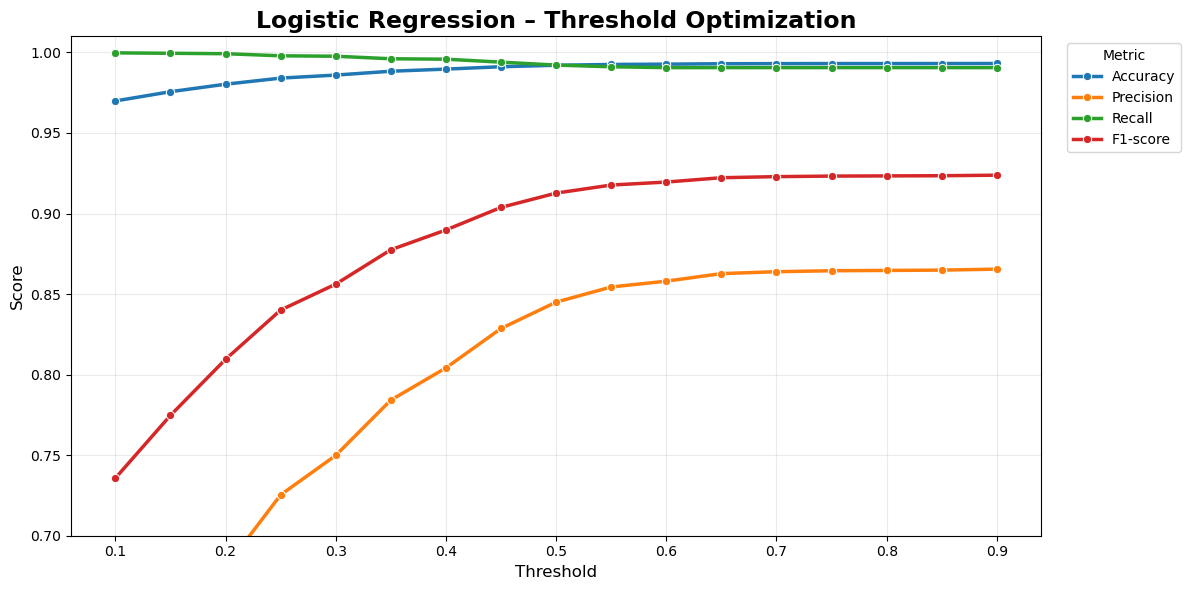

In [47]:
threshold_long = threshold_results_df.melt(
    id_vars="Threshold",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=threshold_long,
    x="Threshold",
    y="Score",
    hue="Metric",
    marker="o",
    linewidth=2.5
)

plt.title("Logistic Regression – Threshold Optimization", fontsize=17, fontweight="bold")
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.70, 1.01)
plt.grid(alpha=0.25)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [48]:
best_threshold = best_threshold_row["Threshold"]

y_pred_log_best_threshold = (y_proba_log >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_val, y_pred_log_best_threshold))
print("Precision:", precision_score(y_val, y_pred_log_best_threshold))
print("Recall:", recall_score(y_val, y_pred_log_best_threshold))
print("F1-score:", f1_score(y_val, y_pred_log_best_threshold))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_log_best_threshold))

Best threshold: 0.9000000000000002
Accuracy: 0.9931489553254795
Precision: 0.8654770075497598
Recall: 0.99057344854674
F1-score: 0.9238095238095239

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.99      0.92      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.99      0.96     91081
weighted avg       0.99      0.99      0.99     91081



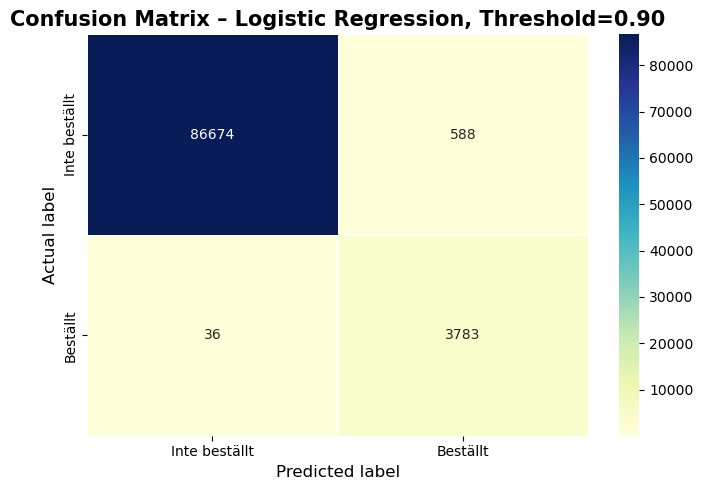

In [49]:
cm_best_threshold = confusion_matrix(y_val, y_pred_log_best_threshold)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_best_threshold,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Inte beställt", "Beställt"],
    yticklabels=["Inte beställt", "Beställt"]
)

plt.title(f"Confusion Matrix – Logistic Regression, Threshold={best_threshold:.2f}", fontsize=15, fontweight="bold")
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("Actual label", fontsize=12)
plt.tight_layout()
plt.show()

### Tolkning av threshold optimization

Standardtröskeln för Logistic Regression är 0.5. I detta steg testades flera olika tröskelvärden mellan 0.10 och 0.90 för att se om modellen kunde få bättre balans mellan precision och recall.

Resultatet visar att F1-score ökade när tröskelvärdet höjdes. Det bästa testade tröskelvärdet var 0.90. Vid denna tröskel fick modellen högre precision och högre F1-score än vid standardtröskeln 0.5, samtidigt som recall fortfarande var mycket hög.

Det innebär att modellen blev mer försiktig med att förutsäga klass 1, men utan att missa många faktiska beställningar. Antalet false positives minskade, medan antalet false negatives bara ökade lite.

Därför kan threshold 0.90 vara ett bättre val än standardtröskeln 0.5 i detta case, särskilt om vi vill minska antalet felaktiga köp-förutsägelser men fortfarande hitta nästan alla faktiska beställningar.

##  Youden’s J-statistik

Youden’s J-statistik används för att hitta ett optimalt tröskelvärde från ROC-kurvan.  
Metoden väljer den punkt där skillnaden mellan True Positive Rate och False Positive Rate är störst.

Formeln är:

J=TPR−FPR

In [50]:
# ROC values for Logistic Regression
fpr_log, tpr_log, thresholds_log = roc_curve(y_val, y_proba_log)

# Youden's J statistic
youden_j = tpr_log - fpr_log

# Find best index
best_index = np.argmax(youden_j)

best_youden_threshold = thresholds_log[best_index]
best_youden_j = youden_j[best_index]

print("Best threshold by Youden's J:", best_youden_threshold)
print("Best Youden's J value:", best_youden_j)
print("TPR / Recall:", tpr_log[best_index])
print("FPR:", fpr_log[best_index])

Best threshold by Youden's J: 0.4216390803042207
Best Youden's J value: 0.9857831473905436
TPR / Recall: 0.9958104215763289
FPR: 0.010027274185785336


In [51]:
y_pred_youden = (y_proba_log >= best_youden_threshold).astype(int)

print("Logistic Regression with Youden's J threshold")
print("Threshold:", best_youden_threshold)
print("Accuracy:", accuracy_score(y_val, y_pred_youden))
print("Precision:", precision_score(y_val, y_pred_youden))
print("Recall:", recall_score(y_val, y_pred_youden))
print("F1-score:", f1_score(y_val, y_pred_youden))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_youden))

Logistic Regression with Youden's J threshold
Threshold: 0.4216390803042207
Accuracy: 0.9902174987099395
Precision: 0.8129542539546815
Recall: 0.9958104215763289
F1-score: 0.8951394609862304

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     87262
           1       0.81      1.00      0.90      3819

    accuracy                           0.99     91081
   macro avg       0.91      0.99      0.95     91081
weighted avg       0.99      0.99      0.99     91081



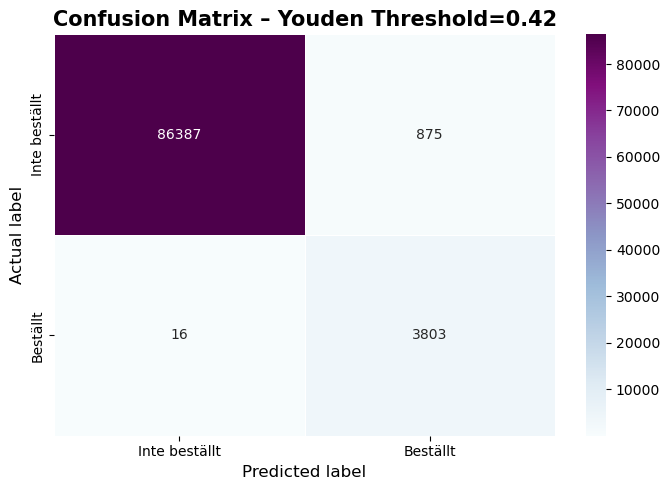

In [52]:
cm_youden = confusion_matrix(y_val, y_pred_youden)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_youden,
    annot=True,
    fmt="d",
    cmap="BuPu",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Inte beställt", "Beställt"],
    yticklabels=["Inte beställt", "Beställt"]
)

plt.title(
    f"Confusion Matrix – Youden Threshold={best_youden_threshold:.2f}",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("Actual label", fontsize=12)
plt.tight_layout()
plt.show()

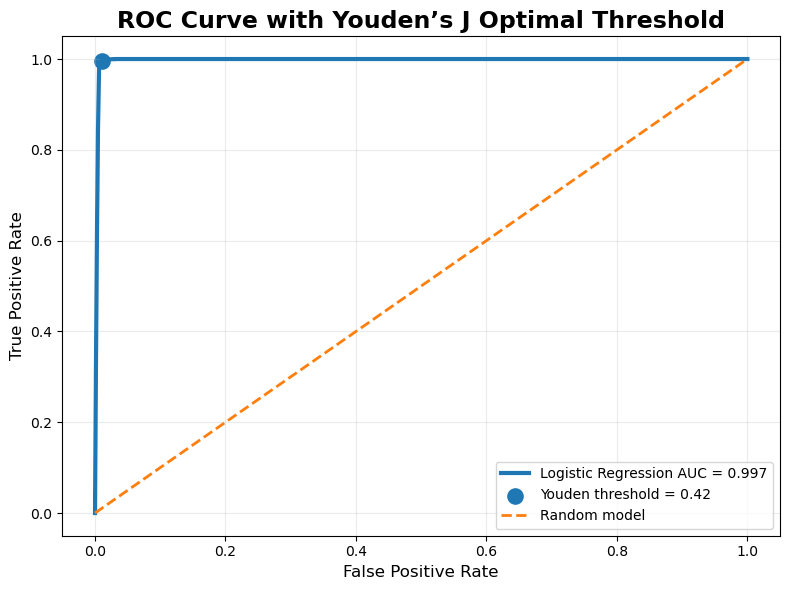

In [53]:
auc_log = roc_auc_score(y_val, y_proba_log)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=3,
    label=f"Logistic Regression AUC = {auc_log:.3f}"
)

plt.scatter(
    fpr_log[best_index],
    tpr_log[best_index],
    s=120,
    label=f"Youden threshold = {best_youden_threshold:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random model"
)

plt.title("ROC Curve with Youden’s J Optimal Threshold", fontsize=17, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [54]:
threshold_comparison = pd.DataFrame({
    "Method": ["Default threshold 0.5", "Best F1 threshold", "Youden's J threshold"],
    "Threshold": [0.5, best_threshold, best_youden_threshold],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_log_best_threshold),
        accuracy_score(y_val, y_pred_youden)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_log_best_threshold),
        precision_score(y_val, y_pred_youden)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_log_best_threshold),
        recall_score(y_val, y_pred_youden)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_log_best_threshold),
        f1_score(y_val, y_pred_youden)
    ]
})

threshold_comparison

,Method,Threshold,Accuracy,Precision,Recall,F1-score
0,Default threshold 0.5,0.500000,0.992040,0.845004,0.992145,0.912682
1,Best F1 threshold,0.900000,0.993149,0.865477,0.990573,0.923810
2,Youden's J threshold,0.421639,0.990217,0.812954,0.995810,0.895139


### Tolkning av Youden’s J-statistik

Youden’s J-statistik valde ett tröskelvärde på cirka 0.42. Detta tröskelvärde gav den högsta recall av de jämförda tröskelvärdena, vilket betyder att modellen hittade nästan alla faktiska beställningar.

Samtidigt blev precisionen lägre än vid både standardtröskeln 0.5 och F1-optimerad threshold 0.90. Det betyder att modellen också skapade fler falska positiva förutsägelser.

Jämförelsen visar att valet av threshold beror på målet. Om det viktigaste är att hitta så många potentiella köpare som möjligt kan Youden’s J vara ett bra val. Om målet däremot är bäst balans mellan precision och recall är threshold 0.90 bättre, eftersom den gav högst F1-score.

##  Feature Importance – Logistic Regression

I den här delen undersöker jag vilka variabler som påverkar Logistic Regression-modellen mest.  
Eftersom Logistic Regression har koefficienter kan vi tolka vilka beteenden som ökar eller minskar sannolikheten för genomförd beställning.

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Abs_Coefficient
13,gatt_till_kassan,3.709789,3.709789
10,kollat_fraktkostnad,1.477326,1.477326
12,loggat_in,-0.577673,0.577673
21,aterkommande_besokare,0.246461,0.246461
0,klickat_varukorgsikon,0.243494,0.243494
2,lagt_till_fran_produktsida,0.228261,0.228261
19,anvant_dator,0.211618,0.211618
1,lagt_till_fran_kategorisida,0.186411,0.186411
22,besokt_fran_svensk_plats,0.174929,0.174929
8,anvant_prissortering,-0.140541,0.140541


C:\Users\mahta\AppData\Local\Temp\ipykernel_12580\3402799119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


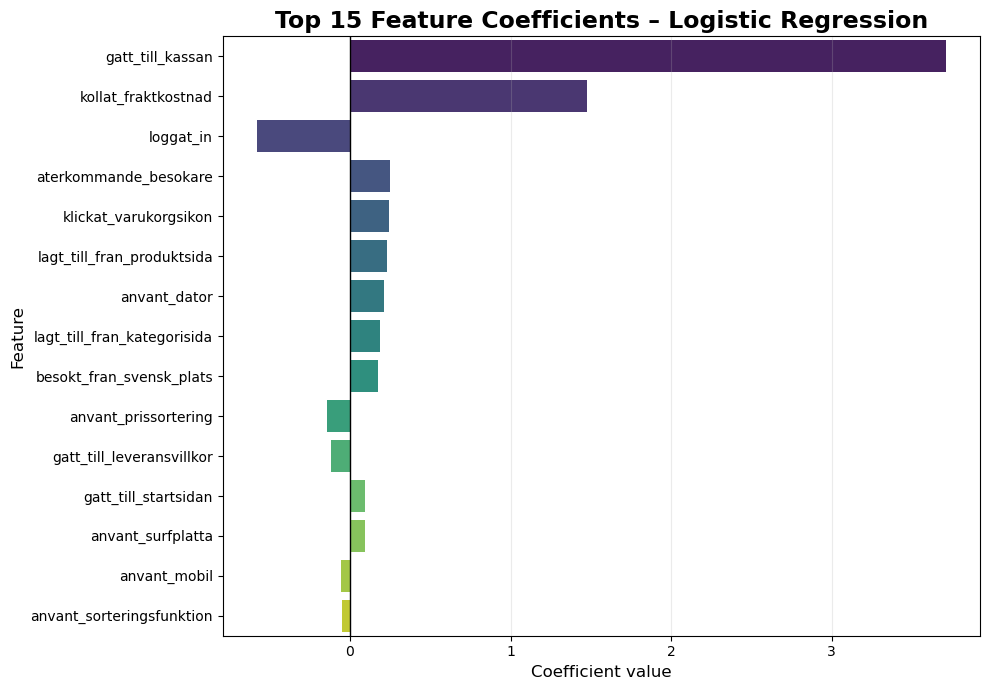

In [56]:
top_features = feature_importance.head(15).copy()

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature",
    palette="viridis"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 Feature Coefficients – Logistic Regression", fontsize=17, fontweight="bold")
plt.xlabel("Coefficient value", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [57]:
feature_importance["Effect"] = np.where(
    feature_importance["Coefficient"] > 0,
    "Increases purchase probability",
    "Decreases purchase probability"
)

feature_importance.head(15)

,Feature,Coefficient,Abs_Coefficient,Effect
13,gatt_till_kassan,3.709789,3.709789,Increases purchase probability
10,kollat_fraktkostnad,1.477326,1.477326,Increases purchase probability
12,loggat_in,-0.577673,0.577673,Decreases purchase probability
21,aterkommande_besokare,0.246461,0.246461,Increases purchase probability
0,klickat_varukorgsikon,0.243494,0.243494,Increases purchase probability
2,lagt_till_fran_produktsida,0.228261,0.228261,Increases purchase probability
19,anvant_dator,0.211618,0.211618,Increases purchase probability
1,lagt_till_fran_kategorisida,0.186411,0.186411,Increases purchase probability
22,besokt_fran_svensk_plats,0.174929,0.174929,Increases purchase probability
8,anvant_prissortering,-0.140541,0.140541,Decreases purchase probability


### Tolkning av feature importance

Logistic Regression visar vilka variabler som har starkast påverkan på modellens prediktioner.  
Positiva koefficienter betyder att beteendet ökar sannolikheten för genomförd beställning, medan negativa koefficienter betyder att beteendet minskar sannolikheten.

De viktigaste variablerna visar vilka steg i kundresan som är starkast kopplade till köp. Exempel kan vara att gå till kassan, logga in, klicka på varukorgen eller kontrollera fraktkostnad.

Detta gör modellen mer tolkbar än KNN, eftersom vi kan se vilka beteenden som påverkar beslutet.

### Tolkning av Logistic Regression-koefficienter

Feature importance visar att `gatt_till_kassan` är den starkaste positiva signalen för genomförd beställning. Det är logiskt eftersom en besökare som går till kassan redan är mycket nära ett köpbeslut.

Även `kollat_fraktkostnad`, `klickat_varukorgsikon`, `lagt_till_fran_produktsida` och `aterkommande_besokare` påverkar sannolikheten för beställning positivt. Dessa variabler visar olika steg i kundresan, från intresse till köpintention.

Variabeln `loggat_in` har en negativ koefficient i modellen. Detta betyder inte nödvändigtvis att inloggning minskar köpviljan i verkligheten. Eftersom modellen analyserar alla variabler samtidigt kan effekten förändras när andra starka variabler, som `gatt_till_kassan` och `kollat_fraktkostnad`, redan finns med i modellen.

Denna del gör Logistic Regression mer tolkbar än KNN, eftersom vi kan se vilka beteenden som påverkar modellens beslut mest.

## 15. Extra Model – Random Forest Classifier

Som en sista extra supervised learning-modell testar jag Random Forest Classifier.  
Random Forest bygger på flera beslutsträd och kan fånga mer komplexa samband mellan variabler än Logistic Regression.  
Eftersom modellen inte är avståndsbaserad behöver vi inte använda skalad data.

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

In [59]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))
print("F1-score:", f1_score(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

Random Forest Results
Accuracy: 0.992621951888978
Precision: 0.8560760353021045
Recall: 0.99057344854674
F1-score: 0.9184268026219956
ROC-AUC: 0.9973316520550607

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.86      0.99      0.92      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.99      0.96     91081
weighted avg       0.99      0.99      0.99     91081



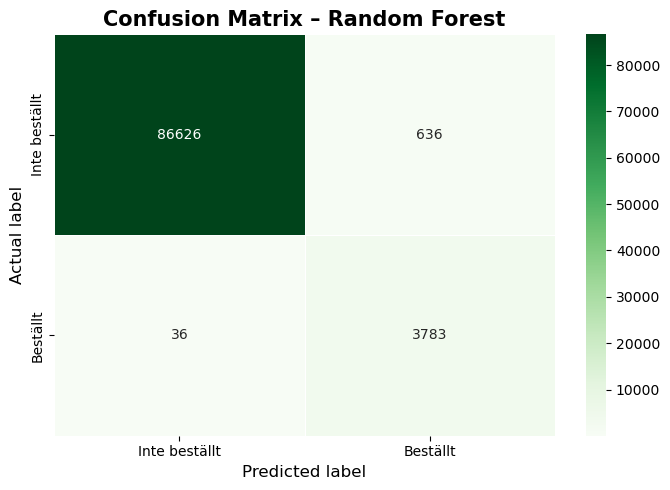

In [60]:
cm_rf = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Inte beställt", "Beställt"],
    yticklabels=["Inte beställt", "Beställt"]
)

plt.title("Confusion Matrix – Random Forest", fontsize=15, fontweight="bold")
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("Actual label", fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
all_models_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression threshold 0.90",
        "Optimized KNN k=15",
        "KNN + PCA",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_log_best_threshold),
        accuracy_score(y_val, y_pred_knn_opt),
        accuracy_score(y_val, y_pred_knn_pca),
        accuracy_score(y_val, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_log_best_threshold),
        precision_score(y_val, y_pred_knn_opt),
        precision_score(y_val, y_pred_knn_pca),
        precision_score(y_val, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_log_best_threshold),
        recall_score(y_val, y_pred_knn_opt),
        recall_score(y_val, y_pred_knn_pca),
        recall_score(y_val, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_log_best_threshold),
        f1_score(y_val, y_pred_knn_opt),
        f1_score(y_val, y_pred_knn_pca),
        f1_score(y_val, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_knn_opt),
        roc_auc_score(y_val, y_proba_knn_pca),
        roc_auc_score(y_val, y_proba_rf)
    ]
})

all_models_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.992040,0.845004,0.992145,0.912682,0.997400
1,Logistic Regression threshold 0.90,0.993149,0.865477,0.990573,0.923810,0.997400
2,Optimized KNN k=15,0.992798,0.868734,0.975648,0.919092,0.994837
3,KNN + PCA,0.991678,0.869597,0.942917,0.904774,0.991127
4,Random Forest,0.992622,0.856076,0.990573,0.918427,0.997332


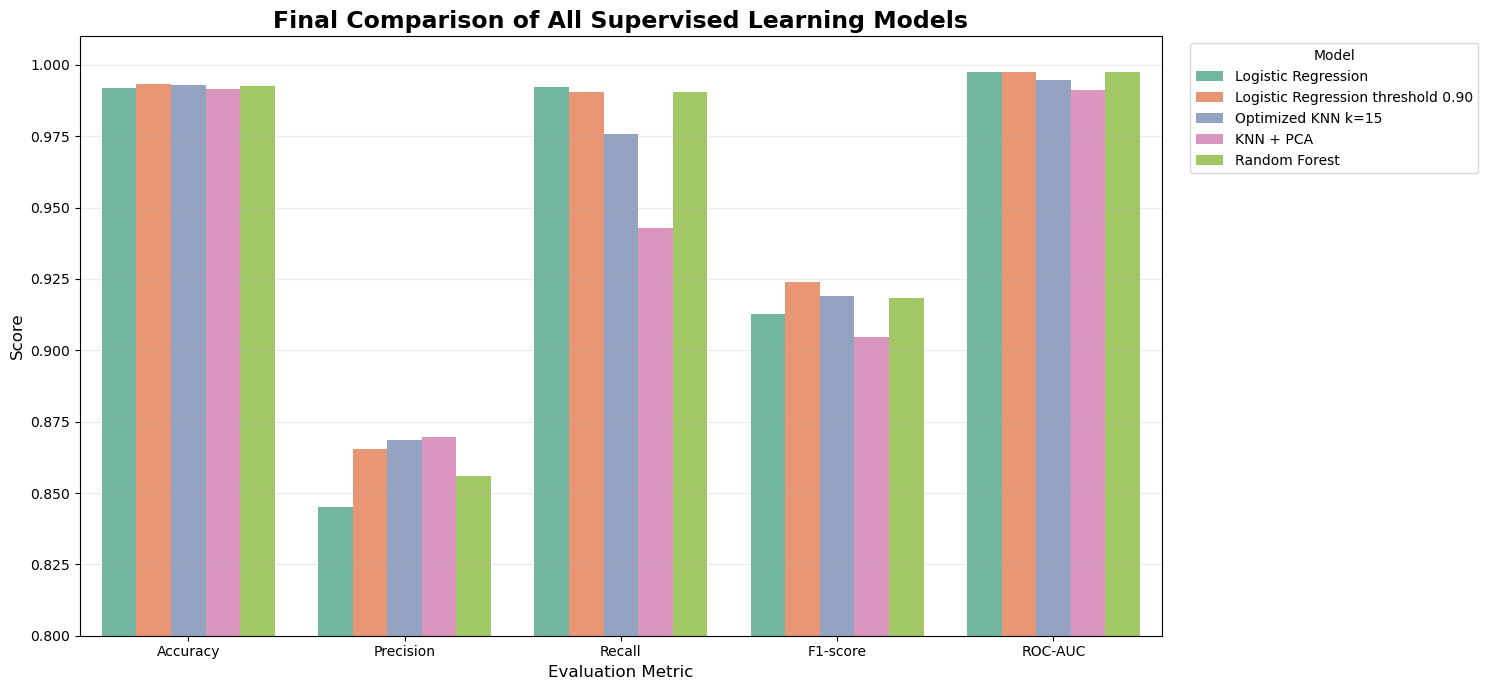

In [62]:
all_models_long = all_models_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 7))

sns.barplot(
    data=all_models_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.title("Final Comparison of All Supervised Learning Models", fontsize=17, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [63]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.head(15)

,Feature,Importance
10,kollat_fraktkostnad,0.332405
13,gatt_till_kassan,0.256096
12,loggat_in,0.237413
2,lagt_till_fran_produktsida,0.078953
0,klickat_varukorgsikon,0.041752
1,lagt_till_fran_kategorisida,0.025576
17,gatt_till_startsidan,0.010625
8,anvant_prissortering,0.008085
9,stangt_liten_varukorg_popup,0.002369
21,aterkommande_besokare,0.001521


C:\Users\mahta\AppData\Local\Temp\ipykernel_12580\530340309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


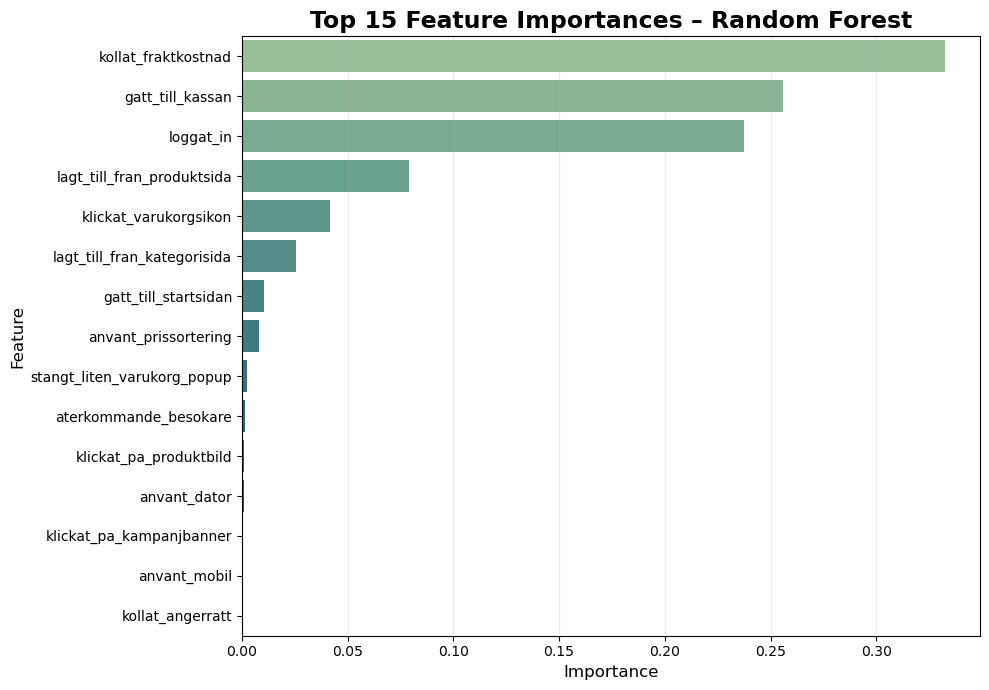

In [64]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature",
    palette="crest"
)

plt.title("Top 15 Feature Importances – Random Forest", fontsize=17, fontweight="bold")
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Tolkning av Random Forest

Random Forest presterar mycket bra och ligger nära Logistic Regression i flera mått. Modellen har hög accuracy, hög recall och mycket hög ROC-AUC. Det betyder att Random Forest också kan skilja mellan besökare som beställer och inte beställer på ett effektivt sätt.

Feature importance från Random Forest visar att de viktigaste variablerna är `kollat_fraktkostnad`, `gatt_till_kassan`, `loggat_in`, `lagt_till_fran_produktsida` och `klickat_varukorgsikon`. Detta bekräftar samma mönster som EDA:n: beteenden sent i kundresan är starkast kopplade till genomförd beställning.

Trots att Random Forest presterar mycket bra är Logistic Regression med threshold 0.90 den bästa modellen i detta projekt, eftersom den har högst F1-score och är lättare att tolka.

## Slutlig modellslutsats

I projektet testades flera supervised learning-modeller: Logistic Regression, KNN, KNN + PCA och Random Forest. Dessutom optimerades KNN genom att testa olika k-värden, och Logistic Regression optimerades genom att testa olika tröskelvärden.

Resultatet visar att alla modeller presterar mycket bra, men Logistic Regression med threshold 0.90 gav bäst helhetsresultat. Den hade högst F1-score och en mycket bra balans mellan precision och recall. Detta är viktigt eftersom datasetet är obalanserat och den positiva klassen, alltså genomförd beställning, är relativt ovanlig.

Random Forest och Optimized KNN presterade också starkt, men Logistic Regression är enklare att tolka och passar bra för ett binärt klassificeringsproblem. Därför väljs Logistic Regression med threshold 0.90 som den bästa modellen i detta case.

Analysen visar också att de viktigaste signalerna för köp är beteenden sent i kundresan, särskilt att besökaren går till kassan, kontrollerar fraktkostnad, loggar in eller interagerar med varukorgen.

Vi testade flera supervised learning-modeller: Logistic Regression, KNN, KNN + PCA och Random Forest. Alla modeller presterade bra, men den bästa modellen blev Logistic Regression med threshold 0.90 eftersom den gav bäst balans mellan precision och recall. Feature importance visade också att beteenden sent i kundresan, till exempel att gå till kassan och kontrollera fraktkostnad, är starkast kopplade till köp.